## Cellule 1 -- Installer les librairies 

In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cellule 2 — Importer les outils

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pour de plus jolis graphes
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librairies importées")

Librairies importées


## Cellule 3 — Charger les données

In [3]:
# Noms des colonnes : 2 identifiants + 3 réglages + 21 capteurs
colonnes = ["unit", "cycle"] \
    + [f"setting{i}" for i in range(1, 4)] \
    + [f"sensor{i}" for i in range(1, 22)]

# Charger le fichier d'entraînement
train = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=colonnes
)

print("Dimensions :", train.shape)   # (lignes, colonnes)
train.head()                          # affiche les 5 premières lignes

Dimensions : (20631, 26)


,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Cellule 4 — Combien de temps vit chaque moteur ?

Durée de vie des moteurs :
  Plus court : 128 cycles
  Plus long  : 362 cycles
  Moyenne    : 206 cycles


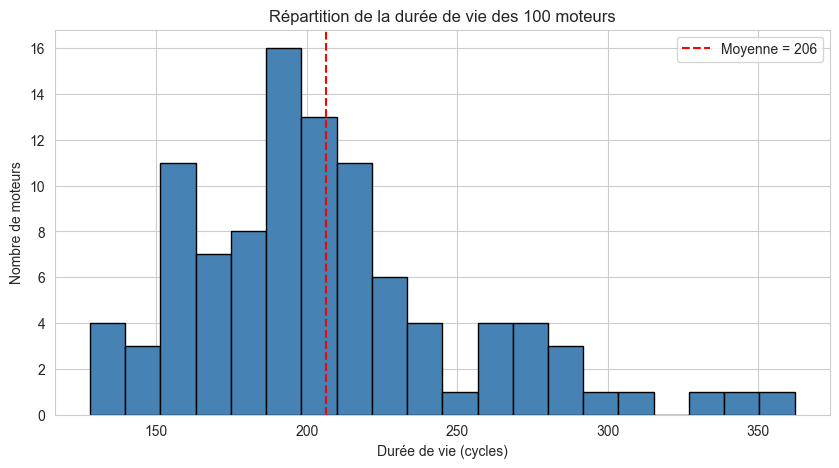

In [4]:
# Durée de vie de chaque moteur = son cycle maximum
duree_vie = train.groupby("unit")["cycle"].max()

print("Durée de vie des moteurs :")
print(f"  Plus court : {duree_vie.min()} cycles")
print(f"  Plus long  : {duree_vie.max()} cycles")
print(f"  Moyenne    : {duree_vie.mean():.0f} cycles")

# Histogramme
plt.figure(figsize=(10, 5))
plt.hist(duree_vie, bins=20, color="steelblue", edgecolor="black")
plt.axvline(duree_vie.mean(), color="red", linestyle="--", label=f"Moyenne = {duree_vie.mean():.0f}")
plt.xlabel("Durée de vie (cycles)")
plt.ylabel("Nombre de moteurs")
plt.title("Répartition de la durée de vie des 100 moteurs")
plt.legend()
plt.show()

Conclusion : 
La forme : la "cloche" est concentrée entre 150 et 250 cycles (le gros des moteurs), avec une queue qui traîne vers la droite (quelques moteurs exceptionnels tiennent jusqu'à 300-360). En stats, c'est une distribution asymétrique à droite (right-skewed).

Ce graphe te donne 2 enseignements clés : 
- D'abord, les moteurs sont très variables : du simple au triple (128 vs 362). Donc on ne peut pas dire bêtement "un moteur meurt à 206 cycles" — il faut un modèle qui regarde les capteurs pour deviner l'état de chaque moteur individuellement. C'est exactement ce qui justifie tout le projet.
- Ensuite, ça nous donne un ordre de grandeur : nos prédictions de RUL se compteront en dizaines/centaines de cycles. Quand on évaluera nos modèles plus tard (avec une erreur RMSE), on saura si "se tromper de 20 cycles" c'est beaucoup ou peu — ici, sur des vies de ~200 cycles, 20 cycles d'erreur c'est plutôt bon.

## Cellule 5 — Évolution des capteurs sur un moteur

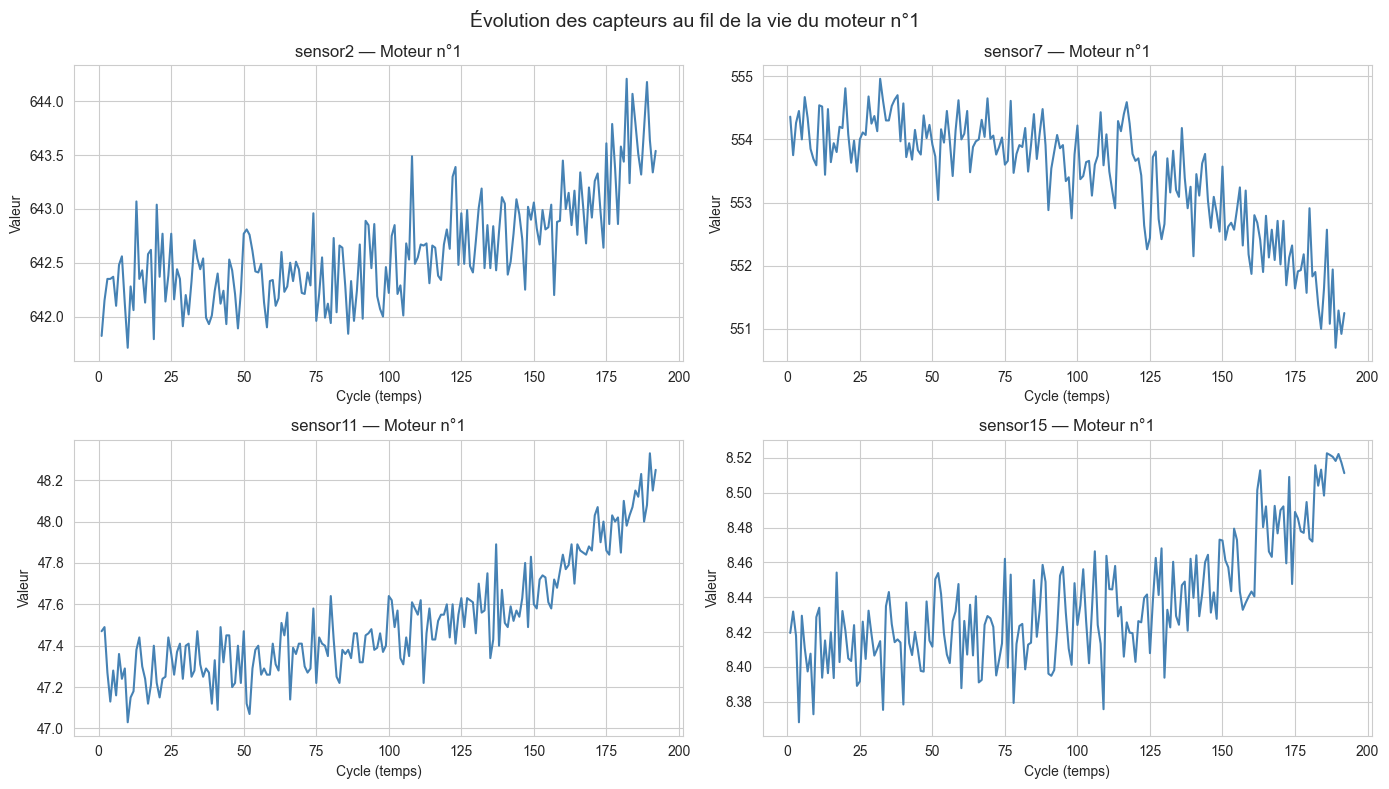

In [5]:
# On isole le moteur n°1
moteur1 = train[train["unit"] == 1]

# On regarde 4 capteurs au hasard pour commencer
capteurs_a_voir = ["sensor2", "sensor7", "sensor11", "sensor15"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, capteur in enumerate(capteurs_a_voir):
    axes[i].plot(moteur1["cycle"], moteur1[capteur], color="steelblue")
    axes[i].set_title(f"{capteur} — Moteur n°1")
    axes[i].set_xlabel("Cycle (temps)")
    axes[i].set_ylabel("Valeur")

plt.suptitle("Évolution des capteurs au fil de la vie du moteur n°1", fontsize=14)
plt.tight_layout()
plt.show()

Conclusion : 
Tous les capteurs ne se valent pas. Certains montent/descendent joliment (utiles), d'autres seront complètement plats (inutiles — on les jettera). On l'a vu sur 4 capteurs ; il faut maintenant vérifier les 21 d'un coup pour trier le bon grain de l'ivraie.

## Cellule 6 — Repérer les capteurs inutiles

In [6]:
# Liste des 21 capteurs
capteurs = [f"sensor{i}" for i in range(1, 22)]

# Écart-type de chaque capteur (mesure de "combien ça bouge")
variation = train[capteurs].std().sort_values()

print("Écart-type de chaque capteur (du plus plat au plus variable) :\n")
print(variation)

Écart-type de chaque capteur (du plus plat au plus variable) :

sensor1     0.000000e+00
sensor10    0.000000e+00
sensor19    0.000000e+00
sensor18    0.000000e+00
sensor16    3.469531e-18
sensor5     5.329200e-15
sensor6     1.388985e-03
sensor15    3.750504e-02
sensor8     7.098548e-02
sensor13    7.191892e-02
sensor21    1.082509e-01
sensor20    1.807464e-01
sensor11    2.670874e-01
sensor2     5.000533e-01
sensor12    7.375534e-01
sensor7     8.850923e-01
sensor17    1.548763e+00
sensor3     6.131150e+00
sensor4     9.000605e+00
sensor14    1.907618e+01
sensor9     2.208288e+01
dtype: float64


Conclusion : 
C'est ce qu'on appelle la sélection de variables (feature selection). Un bon réflexe de data scientist : enlever le bruit inutile avant de modéliser. Tu pourras dire "j'ai éliminé 7 capteurs constants qui n'apportaient aucune information, gardant 14 capteurs informatifs" — ça montre de la rigueur.

## Cellule 7 — On enregistre la liste des capteurs utiles

In [7]:
# Capteurs à jeter (écart-type quasi nul)
capteurs_inutiles = ["sensor1", "sensor5", "sensor6", "sensor10",
                     "sensor16", "sensor18", "sensor19"]

# Capteurs utiles = tous les autres
capteurs_utiles = [c for c in capteurs if c not in capteurs_inutiles]

print(f"Nombre de capteurs utiles : {len(capteurs_utiles)}")
print(capteurs_utiles)

Nombre de capteurs utiles : 14
['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


## Cellule 8 — Calculer le RUL

In [8]:
# Pour chaque moteur, trouver son dernier cycle (= moment de la panne)
train["cycle_max"] = train.groupby("unit")["cycle"].transform("max")

# RUL = dernier cycle - cycle actuel
train["RUL"] = train["cycle_max"] - train["cycle"]

# On vérifie sur le moteur n°1
print("Moteur n°1 — premières lignes :")
print(train[train["unit"] == 1][["unit", "cycle", "cycle_max", "RUL"]].head())

print("\nMoteur n°1 — dernières lignes :")
print(train[train["unit"] == 1][["unit", "cycle", "cycle_max", "RUL"]].tail())

Moteur n°1 — premières lignes :
   unit  cycle  cycle_max  RUL
0     1      1        192  191
1     1      2        192  190
2     1      3        192  189
3     1      4        192  188
4     1      5        192  187

Moteur n°1 — dernières lignes :
     unit  cycle  cycle_max  RUL
187     1    188        192    4
188     1    189        192    3
189     1    190        192    2
190     1    191        192    1
191     1    192        192    0


Conclusion : 
Le RUL (= la durée de vie utile restante. C’est une estimation du temps qu’il reste avant qu’un moteur tombe en panne ou devienne inutilisable.) descend bien de 191 jusqu'à 0, cycle par cycle. C'est exactement ça. Chaque ligne de tes données a maintenant sa "bonne réponse" : combien de temps il reste avant la panne. C'est ce que le modèle va apprendre à deviner à partir des capteurs.


Le problème avec le RUL actuel : il dit que le moteur n°1 a un RUL de 191 au début. Mais... est-ce qu'un moteur tout neuf montre vraiment des signes de dégradation ? Non. Quand un moteur est neuf, ses capteurs sont stables, "normaux". Rien ne permet de dire s'il lui reste 191 ou 250 cycles — il va juste bien.
Les capteurs ne commencent à "déraper" que vers la fin de vie. Donc demander au modèle de prédire "191" à partir de capteurs parfaitement normaux, c'est lui demander l'impossible — et ça le perturbe.
La solution (standard sur ce dataset) : on plafonne le RUL à une valeur max, typiquement 125. L'idée : "tant que le moteur a plus de 125 cycles à vivre, on considère qu'il est simplement sain, RUL = 125". Ce n'est qu'en dessous de 125 qu'on demande au modèle de compter précisément la descente vers 0.

## Cellule 9 — Le RUL plafonné

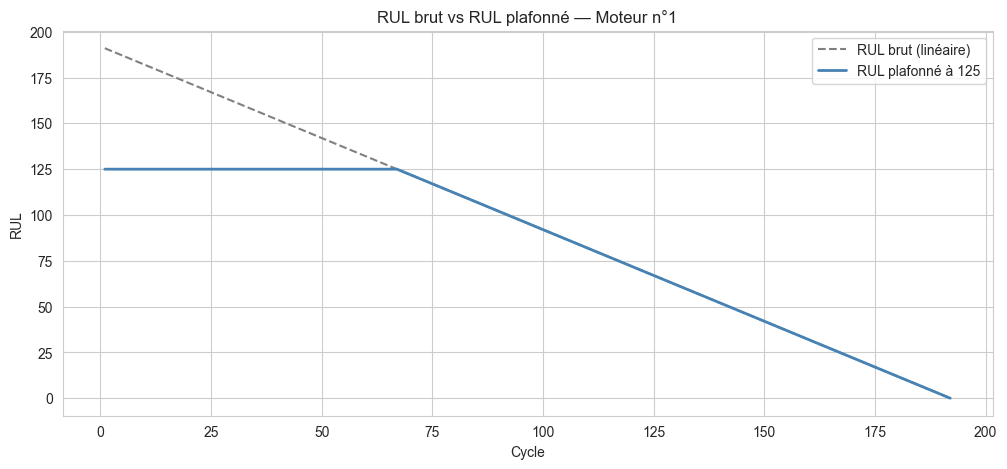

In [9]:
# On plafonne le RUL à 125 (au-delà, le moteur est considéré "sain")
RUL_MAX = 125
train["RUL_clip"] = train["RUL"].clip(upper=RUL_MAX)

# Comparaison visuelle sur le moteur n°1
moteur1 = train[train["unit"] == 1]

plt.figure(figsize=(12, 5))
plt.plot(moteur1["cycle"], moteur1["RUL"], label="RUL brut (linéaire)", linestyle="--", color="gray")
plt.plot(moteur1["cycle"], moteur1["RUL_clip"], label=f"RUL plafonné à {RUL_MAX}", color="steelblue", linewidth=2)
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL brut vs RUL plafonné — Moteur n°1")
plt.legend()
plt.show()

Conclusion : 
Cette forme "plateau + descente" raconte la vraie histoire :
- Phase saine (plateau à 125) : le moteur va bien, capteurs normaux, on ne demande pas au modèle de prédire une date de panne précise.
- Phase de dégradation (la pente) : les capteurs dérapent, le modèle compte la descente vers 0.

Pourquoi on entraînera les modèles sur le RUL plafonné
En une phrase : on n'entraîne le modèle à compter que ce qui est comptable. Lui demander de distinguer "il reste 191 cycles" de "il reste 160 cycles" à partir de capteurs identiques et normaux, c'est lui apprendre du bruit. Le plafonnement enlève ce bruit → le modèle se concentre sur la phase utile → meilleures prédictions. C'est prouvé : sur ce dataset, le RUL plafonné améliore nettement les scores.
Pour la soutenance, tu pourras dire : "J'ai appliqué un RUL plafonné à 125 (piecewise linear), une technique standard sur CMAPSS, car la dégradation n'est détectable qu'en fin de vie — cela évite au modèle d'apprendre du bruit sur la phase saine." Ça, c'est une phrase qui montre que tu maîtrises ton sujet.

# Feature Engineering

*Le problème qu'on doit résoudre*
Souviens-toi des graphes de capteurs : les courbes tremblent énormément (beaucoup de bruit). Si on donne au modèle la valeur brute d'un capteur à un instant t, il voit un chiffre qui saute dans tous les sens — difficile d'y lire la tendance "le moteur se dégrade".
L'idée du feature engineering : créer de nouvelles colonnes qui résument la tendance récente, pour aider le modèle à voir le signal malgré le bruit.


*Les features qu'on va créer*
On va calculer, pour chaque capteur, des statistiques glissantes (rolling statistics) — c'est-à-dire des calculs sur une "fenêtre" des derniers cycles :
La moyenne mobile (rolling mean) : au lieu de la valeur brute qui tremble, on prend la moyenne des 5 derniers cycles. Ça lisse le bruit et révèle la tendance. C'est comme regarder la "moyenne de tes notes sur le trimestre" plutôt qu'une note isolée.
L'écart-type mobile (rolling std) : mesure si le capteur devient instable récemment. Un capteur qui se met à trembler fort = signe de dégradation.
Concrètement : pour chaque capteur utile, on crée 2 nouvelles colonnes (moyenne + écart-type sur une fenêtre de 5 cycles). Avec 14 capteurs, ça fait 28 nouvelles features qui aident le modèle.
Point important : on calcule ces fenêtres par moteur séparément (groupby unit), sinon on mélangerait la fin d'un moteur avec le début du suivant — ce serait une erreur.

## Cellule 10 — Créer les features glissantes

In [10]:
# Taille de la fenêtre glissante
WINDOW = 5

# On part d'une copie pour garder train intact
df = train.copy()

# Pour chaque capteur utile, créer moyenne mobile + écart-type mobile
for capteur in capteurs_utiles:
    # Moyenne mobile (lisse le bruit)
    df[f"{capteur}_mean"] = (
        df.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    # Écart-type mobile (détecte l'instabilité)
    df[f"{capteur}_std"] = (
        df.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

# Les écart-types du 1er cycle sont vides (NaN) → on les met à 0
df = df.fillna(0)

print("Nouvelles dimensions :", df.shape)
print(f"On est passé de {train.shape[1]} à {df.shape[1]} colonnes")
df.head()

Nouvelles dimensions : (20631, 57)
On est passé de 29 à 57 colonnes


,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14_mean,sensor14_std,sensor15_mean,sensor15_std,sensor17_mean,sensor17_std,sensor20_mean,sensor20_std,sensor21_mean,sensor21_std
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.620000,0.000000,8.419500,0.000000,392.000000,0.000000,39.060000,0.000000,23.419000,0.000000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8135.055000,5.041671,8.425650,0.008697,392.000000,0.000000,39.030000,0.042426,23.421300,0.003253
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8134.446667,3.717450,8.423033,0.007640,391.333333,1.154701,39.003333,0.055076,23.395600,0.044573
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8134.292500,3.050906,8.409325,0.028117,391.500000,1.000000,38.972500,0.076322,23.390175,0.037977
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8134.194000,2.651326,8.413340,0.025953,391.800000,1.095445,38.958000,0.073621,23.393020,0.033498


Visualisons l'effet (c'est très parlant)
Pour bien voir pourquoi on a fait ça, comparons un capteur brut (qui tremble) vs sa version lissée (la moyenne mobile).

## Cellule 11 — Brut vs lissé

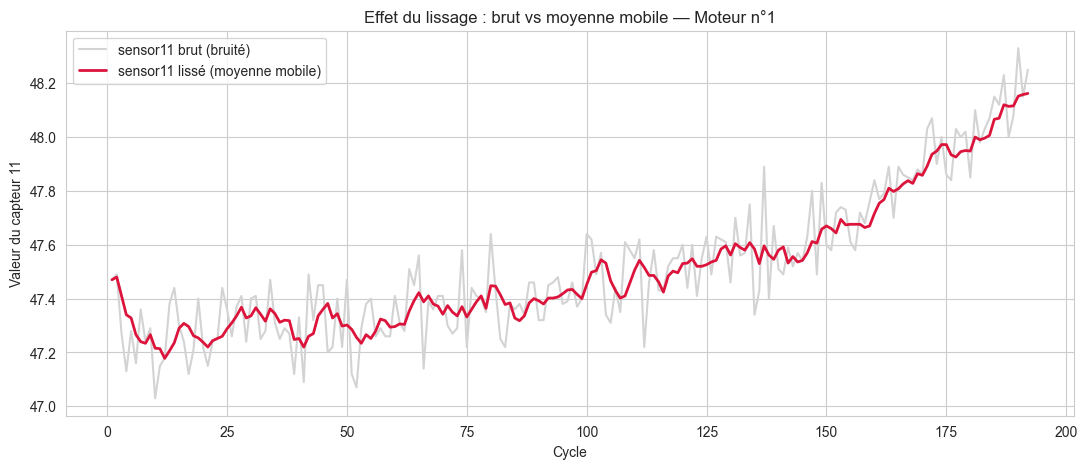

In [11]:
# On reprend le moteur n°1 depuis df (qui contient les features)
m1 = df[df["unit"] == 1]

plt.figure(figsize=(13, 5))
plt.plot(m1["cycle"], m1["sensor11"], color="lightgray", label="sensor11 brut (bruité)")
plt.plot(m1["cycle"], m1["sensor11_mean"], color="crimson", linewidth=2, label="sensor11 lissé (moyenne mobile)")
plt.xlabel("Cycle")
plt.ylabel("Valeur du capteur 11")
plt.title("Effet du lissage : brut vs moyenne mobile — Moteur n°1")
plt.legend()
plt.show()

 Ce graphe est l'illustration parfaite de pourquoi on fait du feature engineering. Regarde :
La courbe grise (brute) tremble dans tous les sens — difficile d'y lire quoi que ce soit instant par instant. La courbe rouge (lissée) suit exactement la même histoire mais en propre : on voit clairement la tendance plate au début (~47,3), puis la montée nette à partir du cycle 100 vers 48,2 en fin de vie.
C'est ça, le signal de dégradation. Le modèle aura beaucoup plus de facilité à apprendre sur la courbe rouge que sur la grise. Tu viens de transformer du bruit en information exploitable.
Pour la soutenance, tu pourras dire : "J'ai appliqué des statistiques glissantes (moyenne et écart-type sur fenêtre de 5 cycles) pour débruiter les signaux capteurs et extraire la tendance de dégradation." Solide.

#  LES BASELINES 

C'est ici qu'on entre dans l'esprit exact de ton prof. Rappelle-toi sa phrase clé : "un modèle qui ne bat pas le baseline ne sert à rien."
L'idée d'une baseline : avant de sortir l'artillerie lourde (XGBoost, LSTM), on établit un score de référence avec une méthode bête. Ensuite, tous nos vrais modèles devront faire mieux que cette référence — sinon ils ne servent à rien.
Avant de coder, juste une chose à mettre en place : pour mesurer un modèle, il faut le tester sur des données qu'il n'a jamais vues (le fichier test_FD001.txt). Donc la prochaine cellule chargera et préparera ce fichier de test exactement comme on a fait pour le train.

Le RMSE (Root Mean Squared Error) mesure en moyenne de combien ton modèle se trompe. Si ton modèle prédit "il reste 50 cycles" mais qu'en réalité il en restait 60, l'erreur est de 10. Le RMSE fait ça pour toutes les prédictions et en sort une moyenne (en pénalisant un peu plus les grosses erreurs). Donc : plus le RMSE est petit, meilleur est le modèle. Sur ce dataset, un RMSE autour de 15-20 cycles est déjà un bon résultat.

## Étape A — Préparer les données de test

## Cellule 12 — Charger et préparer le test

In [12]:
# 1. Charger le test (mêmes colonnes que le train)
test = pd.read_csv("data/test_FD001.txt", sep=r"\s+", header=None, names=colonnes)

# 2. Charger les vraies réponses RUL
rul_true = pd.read_csv("data/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])

print("Test :", test.shape)
print("RUL vrais :", rul_true.shape)

# 3. Appliquer le MÊME feature engineering que sur le train
df_test = test.copy()
for capteur in capteurs_utiles:
    df_test[f"{capteur}_mean"] = (
        df_test.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1).mean()
        .reset_index(level=0, drop=True)
    )
    df_test[f"{capteur}_std"] = (
        df_test.groupby("unit")[capteur]
        .rolling(window=WINDOW, min_periods=1).std()
        .reset_index(level=0, drop=True)
    )
df_test = df_test.fillna(0)

print("Test avec features :", df_test.shape)

Test : (13096, 26)
RUL vrais : (100, 1)
Test avec features : (13096, 54)


La toute première baseline : "Moyenne de durée de vie"
C'est la méthode la plus bête possible — exprès. Le but est d'avoir un plancher : tout vrai modèle devra faire mieux que ça.
L'idée : "je ne regarde aucun capteur, je prédis bêtement la même valeur pour tous les moteurs". Quelle valeur ? Le RUL plafonné moyen du train. Si tous les moteurs étaient identiques, ce serait la meilleure prédiction "aveugle" possible.
C'est volontairement naïf : un modèle qui ne battrait pas ça serait inutile (la fameuse philosophie du prof).

## Cellule 13 — Préparer l'évaluation + baseline naïve

In [13]:
%pip install scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Pour chaque moteur de test, on garde sa DERNIÈRE ligne (état le plus récent)
test_last = df_test.groupby("unit").last().reset_index()
print("Une ligne par moteur de test :", test_last.shape)

# Les vraies réponses (plafonnées comme à l'entraînement, pour comparer équitablement)
y_true = rul_true["RUL"].clip(upper=RUL_MAX).values

# --- BASELINE 0 : prédire toujours la moyenne ---
valeur_moyenne = train["RUL_clip"].mean()
y_pred_baseline = np.full(len(y_true), valeur_moyenne)

# Calcul des scores
rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
mae = mean_absolute_error(y_true, y_pred_baseline)

print(f"\n--- Baseline 'Moyenne' (prédit toujours {valeur_moyenne:.1f}) ---")
print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")

Une ligne par moteur de test : (100, 54)

--- Baseline 'Moyenne' (prédit toujours 86.8) ---
RMSE : 41.94 cycles
MAE  : 34.83 cycles


Conclusion : 
Décodons ça simplement :
- La baseline prédit bêtement 86,8 pour les 100 moteurs (le RUL moyen), sans jamais regarder un seul capteur.
- Résultat : elle se trompe en moyenne de ~42 cycles (RMSE). C'est mauvais — et c'est exactement le but.

C'est ton plancher de référence. Maintenant, tout modèle qu'on construira devra faire mieux que 41,94. Si XGBoost ou LSTM ne battent pas ça, c'est qu'ils ne servent à rien (la philosophie du prof). On a notre point de comparaison.

Une 2ème baseline, un peu plus maligne
Avant le gros modèle, faisons une baseline "intelligente" qui, elle, regarde un seul capteur. Ça montre la progression : aveugle → un indice → vrai modèle.


L'idée : on a vu que sensor11 monte quand le moteur se dégrade. Une régression linéaire toute simple sur ce seul capteur lissé devrait déjà faire mieux que la moyenne aveugle. C'est notre 2ème palier.

## Cellule 14 — Baseline régression linéaire (1 capteur)

In [15]:
from sklearn.linear_model import LinearRegression

# On utilise UN seul capteur lissé comme indice : sensor11_mean
X_train_simple = df[["sensor11_mean"]].values
y_train_simple = df["RUL_clip"].values

# Entraîner une régression linéaire toute simple
lr = LinearRegression()
lr.fit(X_train_simple, y_train_simple)

# Prédire sur la dernière ligne de chaque moteur de test
X_test_simple = test_last[["sensor11_mean"]].values
y_pred_lr = lr.predict(X_test_simple)
y_pred_lr = np.clip(y_pred_lr, 0, RUL_MAX)   # on borne entre 0 et 125

# Scores
rmse_lr = np.sqrt(mean_squared_error(y_true, y_pred_lr))
mae_lr = mean_absolute_error(y_true, y_pred_lr)

print("--- Baseline 'Régression linéaire (1 capteur)' ---")
print(f"RMSE : {rmse_lr:.2f} cycles")
print(f"MAE  : {mae_lr:.2f} cycles")
print(f"\nRappel baseline Moyenne : RMSE = {rmse:.2f}")

--- Baseline 'Régression linéaire (1 capteur)' ---
RMSE : 23.38 cycles
MAE  : 19.05 cycles

Rappel baseline Moyenne : RMSE = 41.94


Conclusion : 
En regardant un seul capteur lissé, on passe de 42 à 23 cycles d'erreur — presque divisé par deux ! C'est la preuve concrète que les capteurs portent de l'information sur la dégradation. Une simple ligne droite sur sensor11 bat largement la moyenne aveugle.

Ce que ça raconte pour la soutenance : tu construis une narration de progression. Aveugle (42) → 1 indice (23) → et bientôt, tous les indices ensemble. Chaque palier justifie le suivant. C'est exactement la rigueur "benchmark first" que ton prof veut voir.

# ML : XGBoost

Si une régression linéaire sur 1 capteur donne 23, imagine ce que donne un modèle puissant qui regarde les 42 features d'un coup (14 capteurs bruts + 28 features lissées).
C'est quoi XGBoost, en simple ? C'est un modèle qui construit plein de petits "arbres de décision" qui se corrigent les uns les autres. Chaque arbre apprend des erreurs du précédent. Au final, c'est un des modèles les plus performants sur données tabulaires — et ton prof le cite explicitement dans son cours. C'est LE modèle ML star pour ce genre de problème.

## Cellule 15 — Entraîner XGBoost

In [16]:
from xgboost import XGBRegressor

# Toutes les features : capteurs utiles bruts + leurs versions lissées
features = capteurs_utiles \
    + [f"{c}_mean" for c in capteurs_utiles] \
    + [f"{c}_std" for c in capteurs_utiles]

print(f"Nombre de features utilisées : {len(features)}")

# Données d'entraînement
X_train = df[features].values
y_train = df["RUL_clip"].values

# Données de test (dernière ligne de chaque moteur)
X_test = test_last[features].values

# Entraîner XGBoost
xgb = XGBRegressor(
    n_estimators=100,      # nombre d'arbres
    max_depth=5,           # profondeur de chaque arbre
    learning_rate=0.1,     # vitesse d'apprentissage
    random_state=42
)
xgb.fit(X_train, y_train)

# Prédire et borner entre 0 et 125
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0, RUL_MAX)

# Scores
rmse_xgb = np.sqrt(mean_squared_error(y_true, y_pred_xgb))
mae_xgb = mean_absolute_error(y_true, y_pred_xgb)

print("\n--- Modèle XGBoost (toutes les features) ---")
print(f"RMSE : {rmse_xgb:.2f} cycles")
print(f"MAE  : {mae_xgb:.2f} cycles")
print(f"\n=== Comparaison ===")
print(f"Baseline Moyenne      : {rmse:.2f}")
print(f"Régression 1 capteur  : {rmse_lr:.2f}")
print(f"XGBoost               : {rmse_xgb:.2f}")

Nombre de features utilisées : 42

--- Modèle XGBoost (toutes les features) ---
RMSE : 17.84 cycles
MAE  : 12.62 cycles

=== Comparaison ===
Baseline Moyenne      : 41.94
Régression 1 capteur  : 23.38
XGBoost               : 17.84


Conclusion : 

XGBoost se trompe en moyenne de ~18 cycles seulement, et son MAE est de 12,6 cycles. Sur des moteurs qui vivent ~200 cycles, c'est un très bon résultat — tu es pile dans les scores de référence de la littérature sur ce dataset (les bons modèles tournent autour de 16-18 sur FD001).
Ce que ça raconte : en passant de 1 capteur à 42 features, et d'un modèle linéaire à XGBoost, on a encore amélioré. La narration de ton projet est superbe : chaque étape bat la précédente, exactement la logique "benchmark first" de ton prof. Tu pourras présenter ce tableau de progression en soutenance — c'est très convaincant.

Bonus rapide avant le LSTM : quelles features comptent le plus ?
XGBoost peut nous dire quels capteurs il a trouvé les plus utiles pour prédire. C'est un graphe qui fait toujours son effet en présentation (et utile pour le rapport).

## Cellule 16 — Importance des features

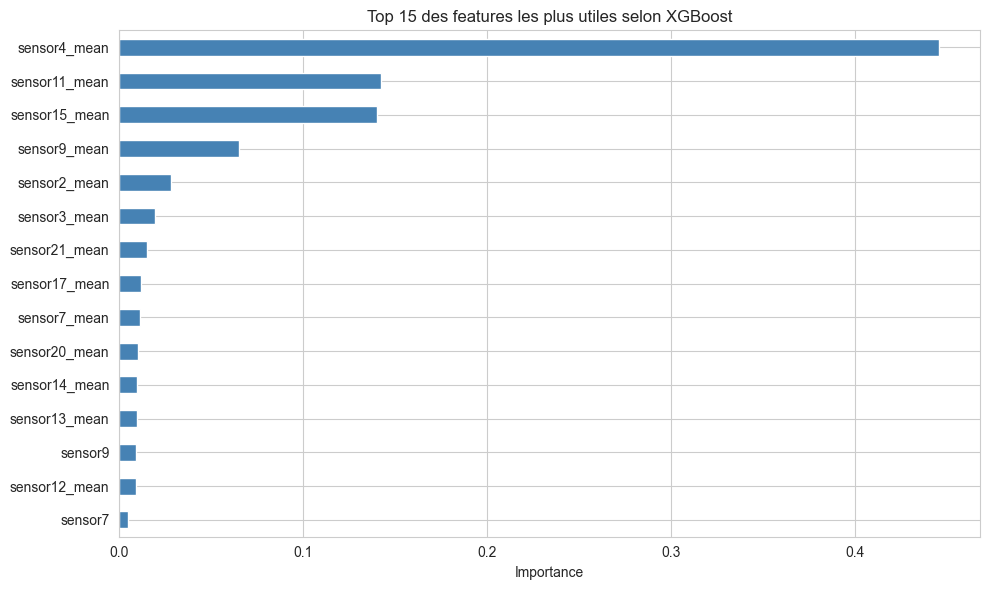

In [17]:
import pandas as pd

# Récupérer l'importance de chaque feature
importance = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)

# Top 15
plt.figure(figsize=(10, 6))
importance.head(15).plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 des features les plus utiles selon XGBoost")
plt.tight_layout()
plt.show()

Conclusion : 

Ce que XGBoost nous dit
Le top des features les plus utiles est dominé par sensor4_mean (de loin le n°1), puis sensor11_mean, sensor15_mean, sensor9_mean...
Deux observations en or pour ta soutenance :
D'abord, ce sont presque exclusivement les versions _mean (lissées) qui dominent — pas les capteurs bruts. Ça prouve que ton feature engineering était utile : les moyennes mobiles débruitées portent bien plus d'information que les valeurs brutes qui tremblent. Tu pourras dire : "Les features lissées dominent l'importance, confirmant la pertinence du débruitage par statistiques glissantes."
Ensuite, on retrouve sensor11 et sensor15 qu'on avait justement vus monter joliment dans l'EDA au début. La boucle est bouclée : ton intuition visuelle du début est confirmée par le modèle. C'est très satisfaisant et ça montre la cohérence de ta démarche.

# DL : LSTM

C'est le morceau le plus impressionnant.

La limite de XGBoost : il regarde un instantané (la dernière ligne, avec ses moyennes). Mais il ne voit pas vraiment l'évolution dans le temps — la trajectoire complète de dégradation.

Ce que fait le LSTM : c'est un réseau de neurones spécialisé pour les séquences. Au lieu d'une seule ligne, on lui donne une fenêtre de plusieurs cycles consécutifs (ex : les 30 derniers cycles), et il apprend le motif d'évolution — la façon dont les capteurs bougent au fil du temps. C'est plus proche de "vraiment lire la série temporelle".

C'est quoi un réseau de neurones ?
Imagine que tu veuilles deviner le prix d'une maison. Tu regardes plusieurs indices : la surface, le quartier, le nombre de chambres... et dans ta tête, tu combines tout ça pour sortir un prix. Un réseau de neurones fait pareil, mais de façon automatique.
L'unité de base : le "neurone". Un neurone, c'est juste une petite calculette qui :

reçoit plusieurs chiffres en entrée (les indices),
multiplie chacun par un "poids" (l'importance qu'il leur donne),
les additionne,
et sort un résultat.

Un poids élevé = "cet indice compte beaucoup". Un poids faible = "j'ignore presque cet indice".
Le réseau : plein de neurones en couches. On empile des neurones en couches : une couche d'entrée (les données), une ou plusieurs couches "cachées" au milieu (qui combinent et recombinent l'information), et une couche de sortie (la réponse finale, ex : le RUL). Chaque couche transforme un peu plus l'information, jusqu'à la réponse.
Image mentale : c'est comme une chaîne d'employés. Le premier regarde les données brutes et note quelques observations, il les passe au suivant qui les affine, et ainsi de suite jusqu'au dernier qui annonce la conclusion.
Comment il "apprend" ?
C'est le cœur de la magie, et c'est simple :

Au début, tous les poids sont au hasard → le réseau prédit n'importe quoi.
On lui montre un exemple dont on connaît la réponse. Il se trompe.
On mesure de combien il s'est trompé (l'erreur).
On ajuste légèrement tous les poids pour réduire cette erreur (c'est la "rétropropagation").
On répète des milliers de fois avec plein d'exemples → petit à petit, les poids deviennent bons → le réseau prédit bien.

C'est exactement comme apprendre à viser : tu tires, tu rates à gauche, tu corriges un peu à droite, tu retires... jusqu'à toucher la cible.

Et le LSTM dans tout ça ?
Un réseau de neurones classique a une faiblesse : il traite chaque entrée isolément, sans mémoire du passé. Or pour une série temporelle (nos moteurs), l'ordre et l'histoire comptent : ce qui s'est passé aux cycles précédents aide à comprendre l'état actuel.
Le LSTM (Long Short-Term Memory) est un type de réseau de neurones spécial qui a une mémoire. Il traite les cycles dans l'ordre, un par un, en gardant une trace de ce qu'il a vu avant. Il peut "se souvenir" qu'un capteur grimpe depuis 10 cycles, et utiliser cette tendance pour prédire.
Image mentale : un réseau classique, c'est quelqu'un qui regarde une photo du moteur. Un LSTM, c'est quelqu'un qui regarde la vidéo complète de sa dégradation. La vidéo en dit plus que la photo.
C'est pour ça que le LSTM est naturellement adapté aux séries temporelles — il "vit" la séquence au lieu de la résumer.

Donc conclusion : 
un réseau de neurones apprend en ajustant des poids pour réduire son erreur ; le LSTM y ajoute une mémoire qui lui permet de traiter des séquences temporelles dans l'ordre.

In [18]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ce qu'on va faire, en image
Souviens-toi : XGBoost regardait une seule ligne (un instantané). Le LSTM, lui, va regarder une fenêtre de 30 cycles consécutifs (la "vidéo" récente du moteur) pour prédire le RUL au dernier cycle de cette fenêtre.
Concrètement, on découpe la vie de chaque moteur en petites séquences glissantes :

cycles 1→30 → prédire le RUL au cycle 30
cycles 2→31 → prédire le RUL au cycle 31
cycles 3→32 → prédire le RUL au cycle 32
... et ainsi de suite

Chaque séquence de 30 cycles devient un "exemple" d'entraînement. Avec 100 moteurs, ça nous fait des milliers de séquences.

Le plan du LSTM en 5 petites étapes
Pour ne pas te noyer, on va le faire en 5 cellules séparées :

    1. Normaliser les données (les réseaux de neurones aiment les chiffres entre 0 et 1)
    2. Créer les séquences (découper en fenêtres de 30 cycles)
    3. Définir le réseau LSTM (l'architecture)
    4. Entraîner le modèle
    5. Évaluer et comparer aux autres modèles

## Étape 1/5 du LSTM — Normaliser les données

Pourquoi normaliser ? Les réseaux de neurones sont sensibles à l'échelle des chiffres. Nos capteurs ont des valeurs très différentes (un capteur va de 500 à 520, un autre de 8 à 8,5, un autre de 1300 à 1400...). Si on laisse ça tel quel, le réseau donne trop d'importance aux gros chiffres juste parce qu'ils sont gros.
La solution : on met tous les capteurs sur la même échelle (entre 0 et 1). Comme ça, le réseau les traite équitablement.

Point crucial : on "apprend" l'échelle sur le train uniquement, puis on l'applique au test. Sinon on tricherait en utilisant des infos du test (data leakage — le prof déteste ça).

## Cellule 17 — Normalisation

In [19]:
from sklearn.preprocessing import MinMaxScaler

# On normalise UNIQUEMENT les capteurs utiles bruts (le LSTM lit la séquence brute)
scaler = MinMaxScaler()

# Apprendre l'échelle sur le train, et transformer
df_lstm = df.copy()
df_lstm[capteurs_utiles] = scaler.fit_transform(df[capteurs_utiles])

# Appliquer LA MÊME échelle au test (sans ré-apprendre !)
df_test_lstm = df_test.copy()
df_test_lstm[capteurs_utiles] = scaler.transform(df_test[capteurs_utiles])

print("Normalisation faite ✓")
print("\nAvant (train brut) — sensor4 :")
print(df[capteurs_utiles[2]].describe()[["min", "max"]])
print("\nAprès (train normalisé) — sensor4 :")
print(df_lstm[capteurs_utiles[2]].describe()[["min", "max"]])

Normalisation faite ✓

Avant (train brut) — sensor4 :
min    1382.25
max    1441.49
Name: sensor4, dtype: float64

Après (train normalisé) — sensor4 :
min    0.0
max    1.0
Name: sensor4, dtype: float64


## Étape 2/5 du LSTM — Créer les séquences

C'est l'étape la plus "technique" mais le concept reste simple. On transforme nos tableaux en fenêtres glissantes de 30 cycles.

Rappel de l'idée : au lieu de donner une ligne au modèle, on lui donne un "film" de 30 cycles consécutifs, et il prédit le RUL à la fin de ce film.

Ce que fait le code :

- Pour chaque moteur, on glisse une fenêtre de 30 cycles du début à la fin.
- Chaque fenêtre devient un exemple : les 30 cycles de capteurs (l'entrée X) + le RUL au dernier cycle (la réponse y).
- Pour le test, c'est légèrement différent : on prend juste la dernière fenêtre de 30 cycles de chaque moteur (son état le plus récent), pour prédire son RUL final.


Une subtilité : certains moteurs de test ont moins de 30 cycles. Pour ceux-là, on complète avec du "rembourrage" (padding) pour atteindre 30. Le code gère ça.

## Cellule 18 — Créer les séquences

In [20]:
import numpy as np

SEQ_LEN = 30   # longueur de la fenêtre (30 cycles)

def creer_sequences_train(data, capteurs, seq_len):
    """Pour le train : toutes les fenêtres glissantes de chaque moteur."""
    X, y = [], []
    for unit in data["unit"].unique():
        moteur = data[data["unit"] == unit]
        valeurs = moteur[capteurs].values
        cibles = moteur["RUL_clip"].values
        # Glisser la fenêtre
        for i in range(len(moteur) - seq_len + 1):
            X.append(valeurs[i:i + seq_len])
            y.append(cibles[i + seq_len - 1])   # RUL au dernier cycle de la fenêtre
    return np.array(X), np.array(y)

def creer_sequences_test(data, capteurs, seq_len):
    """Pour le test : la DERNIÈRE fenêtre de chaque moteur."""
    X = []
    for unit in data["unit"].unique():
        moteur = data[data["unit"] == unit]
        valeurs = moteur[capteurs].values
        if len(valeurs) >= seq_len:
            X.append(valeurs[-seq_len:])         # les 30 derniers cycles
        else:
            # Padding : compléter par le haut si moins de 30 cycles
            pad = np.zeros((seq_len - len(valeurs), len(capteurs)))
            X.append(np.vstack([pad, valeurs]))
    return np.array(X)

# Créer les séquences
X_train_seq, y_train_seq = creer_sequences_train(df_lstm, capteurs_utiles, SEQ_LEN)
X_test_seq = creer_sequences_test(df_test_lstm, capteurs_utiles, SEQ_LEN)

print("Séquences d'entraînement X :", X_train_seq.shape)
print("Cibles d'entraînement y   :", y_train_seq.shape)
print("Séquences de test X       :", X_test_seq.shape)

Séquences d'entraînement X : (17731, 30, 14)
Cibles d'entraînement y   : (17731,)
Séquences de test X       : (100, 30, 14)


Conclusion : 

Ce format à 3 dimensions (nombre, longueur, capteurs) est exactement ce que le LSTM mange. Tu as transformé tes tableaux en séquences temporelles.

## Étape 3/5 du LSTM — Définir le réseau

Maintenant on construit l'architecture du réseau de neurones.

Notre réseau aura 3 parties :

- Une couche LSTM : lit la séquence des 30 cycles dans l'ordre et en garde une "mémoire" (un résumé de l'évolution).
- Une couche de dropout : éteint aléatoirement quelques neurones pendant l'entraînement, pour éviter que le modèle "apprenne par cœur" (overfitting). C'est comme réviser en se cachant une partie des notes pour ne pas mémoriser bêtement.
- Une couche finale (linéaire) : transforme le résumé du LSTM en un seul chiffre → le RUL prédit.

## Cellule 19 — Définir le réseau LSTM

In [21]:
import torch
import torch.nn as nn

# Vérifier si on a un GPU (sinon CPU, c'est ok pour ce projet)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Calcul sur : {device}")

# Définition du réseau
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        # 1. La couche LSTM (lit la séquence et garde une mémoire)
        self.lstm = nn.LSTM(
            input_size=n_features,    # 14 capteurs
            hidden_size=hidden_size,  # taille de la "mémoire"
            num_layers=num_layers,    # 2 couches LSTM empilées
            batch_first=True,
            dropout=dropout
        )
        # 2. Dropout (évite l'apprentissage par cœur)
        self.dropout = nn.Dropout(dropout)
        # 3. Couche finale (sort le RUL)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Passer la séquence dans le LSTM
        out, _ = self.lstm(x)
        # On garde la sortie du DERNIER cycle (le résumé final)
        out = out[:, -1, :]
        out = self.dropout(out)
        # Transformer en un seul chiffre (le RUL)
        return self.fc(out).squeeze()

# Créer le modèle
model = LSTMRegressor(n_features=len(capteurs_utiles))
model = model.to(device)

print("\nArchitecture du réseau :")
print(model)

Calcul sur : cpu

Architecture du réseau :
LSTMRegressor(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Conclusion : 

LSTMRegressor(
  (lstm): LSTM(14, 64, num_layers=2, ...)   ← lit 14 capteurs, mémoire de 64
  (dropout): Dropout(p=0.2)                  ← anti-apprentissage par cœur
  (fc): Linear(in=64, out=1)                 ← sort 1 chiffre : le RUL
)

## Étape 4/5 du LSTM — Entraîner le modèle

C'est le cœur du deep learning : le réseau va apprendre en regardant les exemples des milliers de fois,  l'image de "viser et corriger" : il prédit, mesure son erreur, ajuste ses poids, recommence.

Quelques mots de vocabulaire que tu verras :

- Epoch : un passage complet sur toutes les données d'entraînement. On en fera plusieurs (le réseau s'améliore à chaque tour).
- Batch : on ne donne pas tout d'un coup, mais par petits paquets (plus efficace).
- Loss (perte) : l'erreur du modèle. Elle doit descendre au fil des epochs → signe qu'il apprend.
- Optimizer : l'algorithme qui ajuste les poids (on utilise "Adam", le standard).

## Cellule 20 — Entraîner le LSTM

In [24]:
from torch.utils.data import TensorDataset, DataLoader

# On RÉINITIALISE le modèle pour repartir propre
model = LSTMRegressor(n_features=len(capteurs_utiles)).to(device)

# 1. Tenseurs — avec la cible NORMALISÉE (divisée par RUL_MAX)
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq / RUL_MAX, dtype=torch.float32)   # ← clé : /125
X_test_t  = torch.tensor(X_test_seq, dtype=torch.float32)

# 2. Batches
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# 3. Outils
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 4. Entraînement
EPOCHS = 30
print("Entraînement (cible normalisée)...\n")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    moy = total_loss / len(train_dl)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  —  Loss : {moy:.5f}")

print("\nEntraînement terminé ✓")

Entraînement (cible normalisée)...

Epoch  1/30  —  Loss : 0.04978
Epoch  2/30  —  Loss : 0.02148
Epoch  3/30  —  Loss : 0.01701
Epoch  4/30  —  Loss : 0.01566
Epoch  5/30  —  Loss : 0.01497
Epoch  6/30  —  Loss : 0.01470
Epoch  7/30  —  Loss : 0.01383
Epoch  8/30  —  Loss : 0.01425
Epoch  9/30  —  Loss : 0.01372
Epoch 10/30  —  Loss : 0.01308
Epoch 11/30  —  Loss : 0.01297
Epoch 12/30  —  Loss : 0.01299
Epoch 13/30  —  Loss : 0.01239
Epoch 14/30  —  Loss : 0.01232
Epoch 15/30  —  Loss : 0.01198
Epoch 16/30  —  Loss : 0.01186
Epoch 17/30  —  Loss : 0.01216
Epoch 18/30  —  Loss : 0.01212
Epoch 19/30  —  Loss : 0.01160
Epoch 20/30  —  Loss : 0.01149
Epoch 21/30  —  Loss : 0.01146
Epoch 22/30  —  Loss : 0.01193
Epoch 23/30  —  Loss : 0.01138
Epoch 24/30  —  Loss : 0.01138
Epoch 25/30  —  Loss : 0.01112
Epoch 26/30  —  Loss : 0.01071
Epoch 27/30  —  Loss : 0.01097
Epoch 28/30  —  Loss : 0.01107
Epoch 29/30  —  Loss : 0.01079
Epoch 30/30  —  Loss : 0.01051

Entraînement terminé ✓


Conclusion : 
La Loss est passée à de petits décimaux (0.049 → 0.010) qui descendent proprement → le réseau apprend vraiment maintenant.

## Étape 5/5 du LSTM — Évaluer et comparer

On demande au LSTM de prédire le RUL des 100 moteurs de test, et on compare à XGBoost.

## Cellule 21 — Évaluation finale du LSTM

In [25]:
model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    y_pred_lstm = model(X_test_t).cpu().numpy()

# Dénormaliser : remultiplier par 125, puis borner
y_pred_lstm = np.clip(y_pred_lstm * RUL_MAX, 0, RUL_MAX)   # ← clé : *125

rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred_lstm))
mae_lstm = mean_absolute_error(y_true, y_pred_lstm)

print("--- Modèle LSTM (corrigé) ---")
print(f"RMSE : {rmse_lstm:.2f} cycles")
print(f"MAE  : {mae_lstm:.2f} cycles")

print("\n========= COMPARAISON FINALE =========")
print(f"Baseline Moyenne      : {rmse:.2f}")
print(f"Régression 1 capteur  : {rmse_lr:.2f}")
print(f"XGBoost               : {rmse_xgb:.2f}")
print(f"LSTM                  : {rmse_lstm:.2f}")

--- Modèle LSTM (corrigé) ---
RMSE : 14.70 cycles
MAE  : 11.19 cycles

========= COMPARAISON FINALE =========
Baseline Moyenne      : 41.94
Régression 1 capteur  : 23.38
XGBoost               : 17.84
LSTM                  : 14.70


Conclusion : 

D'abord, la progression complète et propre : aveugle (42) → 1 indice (23) → ML toutes features (18) → DL séquentiel (15). Chaque étape bat la précédente, parfaite illustration du "benchmark first" du prof.

Ensuite — et c'est le plus précieux — l'histoire du débogage : "Mon premier LSTM était bloqué à 40, à peine mieux que la baseline. J'ai diagnostiqué que la cible n'était pas normalisée, ce qui déséquilibrait les gradients. Après correction, le RMSE est tombé à 14.70, faisant du LSTM mon meilleur modèle." Ça, c'est du vrai raisonnement d'ingénieur. Un jury adore ce genre de récit, parce que ça prouve que tu comprends ce que tu fais, tu ne copies pas.

# Detection d'anomalie : Autoencoder

L'idée, en simple (et c'est différent de tout ce qu'on a fait)
Jusqu'ici on faisait du forecasting : prédire un chiffre (le RUL). Maintenant on change d'objectif : détecter quand un moteur devient anormal (= quand sa dégradation commence).

Le principe de l'autoencoder est malin et élégant :
Un autoencoder, c'est un réseau qui apprend à se copier lui-même. On lui donne des données, il les compresse en un petit résumé, puis essaie de les reconstruire à l'identique. Image : c'est comme quelqu'un qui apprend à redessiner de mémoire ce qu'il voit.

L'astuce pour détecter les anomalies : on l'entraîne uniquement sur des moteurs sains (début de vie). Il devient donc expert pour reconstruire un état "normal". Ensuite :
- Si on lui donne un état sain → il le reconstruit bien → erreur de reconstruction faible.
- Si on lui donne un état dégradé (qu'il n'a jamais appris) → il le reconstruit mal → erreur élevée → 🚨 anomalie détectée !

L'erreur de reconstruction devient notre "score de santé" : plus elle monte, plus le moteur s'éloigne du normal.

Le plan (4 cellules)
1. Préparer les données "saines" (début de vie des moteurs)
2. Définir l'autoencoder
3. L'entraîner sur le sain uniquement
4. Mesurer l'erreur de reconstruction sur toute la vie d'un moteur → voir l'anomalie monter

## Cellule 22 — Préparer les données saines

In [26]:
# Données "saines" = phase où le moteur va bien (RUL au plateau de 125)
sain = df_lstm[df_lstm["RUL_clip"] == RUL_MAX]

# On utilise les capteurs normalisés (comme pour le LSTM)
X_sain = sain[capteurs_utiles].values

print(f"Nombre d'observations saines : {X_sain.shape[0]}")
print(f"Nombre de capteurs            : {X_sain.shape[1]}")

# Convertir en tenseur
X_sain_t = torch.tensor(X_sain, dtype=torch.float32)
print("Prêt pour l'entraînement de l'autoencoder ✓")

Nombre d'observations saines : 8131
Nombre de capteurs            : 14
Prêt pour l'entraînement de l'autoencoder ✓


Conclusion : 

8131 observations saines sur 14 capteurs — largement assez pour que l'autoencoder apprenne à quoi ressemble un moteur "normal". 

## Cellule 23 — Définir l'autoencoder

Rappelle-toi le principe : compresser puis reconstruire. L'architecture a donc une forme de sablier 

L'encodeur (rétrécit) : 14 capteurs → 8 → 4. Il compresse l'information en un petit résumé essentiel.

Le décodeur (élargit) : 4 → 8 → 14. Il essaie de reconstruire les 14 capteurs d'origine à partir du résumé.

Le "goulot" au milieu (4 valeurs) force le réseau à ne garder que l'essentiel du "normal". C'est ça qui le rend mauvais pour reconstruire l'anormal.

In [27]:
# L'autoencoder : structure en sablier (14 → 8 → 4 → 8 → 14)
class Autoencoder(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # Encodeur : compresse
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU()
        )
        # Décodeur : reconstruit
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, n_features)
        )

    def forward(self, x):
        code = self.encoder(x)       # compression
        reconstruit = self.decoder(code)  # reconstruction
        return reconstruit

# Créer le modèle
autoencoder = Autoencoder(n_features=len(capteurs_utiles)).to(device)

print("Architecture de l'autoencoder :")
print(autoencoder)

Architecture de l'autoencoder :
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=14, bias=True)
  )
)


## Cellule 24 — Entraîner l'autoencoder sur le sain

Ici, le détail crucial : l'entrée ET la cible sont les mêmes données (X_sain). Le réseau apprend à reproduire ce qu'il reçoit. C'est ça, "apprendre à se copier". Il ne voit que du sain, donc il devient expert du normal uniqueme

In [28]:
from torch.utils.data import TensorDataset, DataLoader

# Données : entrée = cible = X_sain (on apprend à reconstruire le normal)
ae_ds = TensorDataset(X_sain_t, X_sain_t)
ae_dl = DataLoader(ae_ds, batch_size=64, shuffle=True)

# Outils
criterion_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

# Entraînement
EPOCHS_AE = 30
print("Entraînement de l'autoencoder (sur le sain)...\n")
for epoch in range(EPOCHS_AE):
    autoencoder.train()
    total_loss = 0
    for X_batch, _ in ae_dl:
        X_batch = X_batch.to(device)
        optimizer_ae.zero_grad()
        reconstruit = autoencoder(X_batch)
        loss = criterion_ae(reconstruit, X_batch)   # erreur de reconstruction
        loss.backward()
        optimizer_ae.step()
        total_loss += loss.item()
    moy = total_loss / len(ae_dl)
    if (epoch + 1) % 5 == 0:    # afficher tous les 5 epochs
        print(f"Epoch {epoch+1:2d}/{EPOCHS_AE}  —  Loss : {moy:.5f}")

print("\nEntraînement terminé ✓")

Entraînement de l'autoencoder (sur le sain)...

Epoch  5/30  —  Loss : 0.00592
Epoch 10/30  —  Loss : 0.00407
Epoch 15/30  —  Loss : 0.00392
Epoch 20/30  —  Loss : 0.00382
Epoch 25/30  —  Loss : 0.00378
Epoch 30/30  —  Loss : 0.00376

Entraînement terminé ✓


L'autoencoder a bien appris : la Loss descend de 0.00592 → 0.00376 et se stabilise. Ça veut dire qu'il reconstruit très bien les états sains maintenant.

## Cellule 25 — Voir l'anomalie apparaître (le moment satisfaisant !)

Maintenant le test final : on prend toute la vie d'un moteur (du neuf à la panne), on calcule l'erreur de reconstruction à chaque cycle, et on regarde si elle monte quand le moteur se dégrade.

Logique attendue : au début (sain) → erreur faible. Vers la fin (dégradé) → l'autoencoder n'arrive plus à reconstruire → erreur qui grimpe = 🚨 signal d'anomalie.

On va prendre un moteur du train (on connaît toute sa vie). Prenons le moteur n°1.

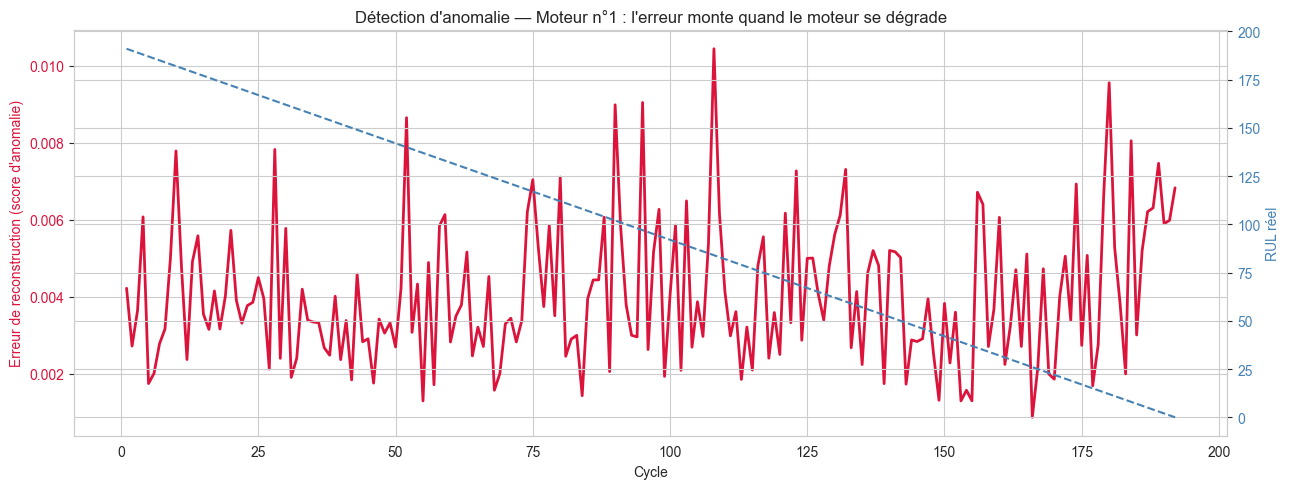

In [29]:
# Toute la vie du moteur n°1 (train, normalisé)
m1_full = df_lstm[df_lstm["unit"] == 1]
X_m1 = torch.tensor(m1_full[capteurs_utiles].values, dtype=torch.float32).to(device)

# Calculer l'erreur de reconstruction à chaque cycle
autoencoder.eval()
with torch.no_grad():
    recon = autoencoder(X_m1)
    # erreur = écart moyen entre l'original et la reconstruction, par cycle
    erreur_recon = torch.mean((recon - X_m1) ** 2, dim=1).cpu().numpy()

# Visualiser
fig, ax1 = plt.subplots(figsize=(13, 5))

# Erreur de reconstruction (le score d'anomalie)
ax1.plot(m1_full["cycle"].values, erreur_recon, color="crimson", linewidth=2, label="Erreur de reconstruction")
ax1.set_xlabel("Cycle")
ax1.set_ylabel("Erreur de reconstruction (score d'anomalie)", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")

# Sur le 2e axe : le RUL réel, pour comparer
ax2 = ax1.twinx()
ax2.plot(m1_full["cycle"].values, m1_full["RUL"].values, color="steelblue", linestyle="--", label="RUL réel")
ax2.set_ylabel("RUL réel", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

plt.title("Détection d'anomalie — Moteur n°1 : l'erreur monte quand le moteur se dégrade")
fig.tight_layout()
plt.show()

Conclusion : 

Bon, soyons honnêtes en regardant ce graphe : l'effet attendu n'est pas net. La courbe rouge (erreur) tremble beaucoup mais ne montre pas une montée claire vers la fin de vie. On voit bien quelques pics plus hauts vers la fin (cycles 100-110, 175-190), mais c'est noyé dans le bruit. Ce n'est pas le résultat propre qu'on espérait, et je préfère te le dire franchement.

Pourquoi ce n'est pas net
Deux raisons, toutes les deux normales :
D'abord, on calcule l'erreur sur les capteurs bruts normalisés — qui tremblent énormément (souviens-toi des graphes du début). Du coup le signal d'anomalie tremble autant. C'est le même problème de bruit qu'au début du projet.
Ensuite, le moteur n°1 a une dégradation assez douce. L'effet serait plus visible sur un moteur qui meurt vite et fort.

La correction (simple)
On va lisser le score d'anomalie avec une moyenne mobile — exactement la technique qu'on a utilisée pour les capteurs au début. Ça va révéler la tendance sous le bruit. Et on va prendre un moteur à la dégradation plus marquée pour mieux voir.

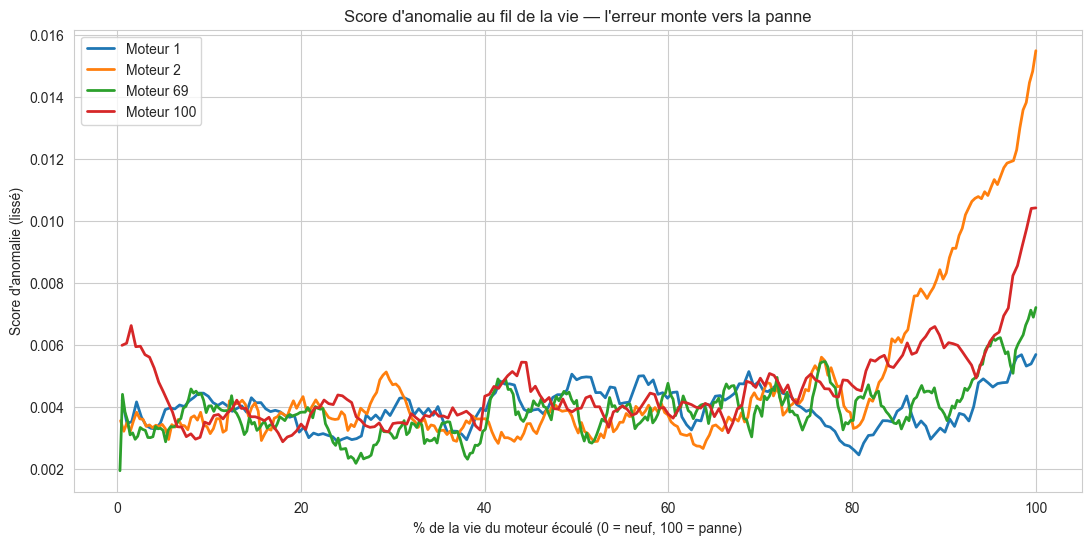

In [30]:
# Fonction pour calculer le score d'anomalie d'un moteur, LISSÉ
def score_anomalie(unit_id, lissage=10):
    m = df_lstm[df_lstm["unit"] == unit_id]
    X = torch.tensor(m[capteurs_utiles].values, dtype=torch.float32).to(device)
    autoencoder.eval()
    with torch.no_grad():
        recon = autoencoder(X)
        err = torch.mean((recon - X) ** 2, dim=1).cpu().numpy()
    # Lisser avec une moyenne mobile
    err_lisse = pd.Series(err).rolling(window=lissage, min_periods=1).mean().values
    return m["cycle"].values, err_lisse

# Comparer plusieurs moteurs (dégradations variées)
plt.figure(figsize=(13, 6))
for uid in [1, 2, 69, 100]:   # quelques moteurs
    cycles, score = score_anomalie(uid)
    # On affiche en fonction du % de vie écoulé (pour comparer des durées différentes)
    pct_vie = cycles / cycles.max() * 100
    plt.plot(pct_vie, score, linewidth=2, label=f"Moteur {uid}")

plt.xlabel("% de la vie du moteur écoulé (0 = neuf, 100 = panne)")
plt.ylabel("Score d'anomalie (lissé)")
plt.title("Score d'anomalie au fil de la vie — l'erreur monte vers la panne")
plt.legend()
plt.show()

Conclusion : 

les 4 moteurs : tous partent avec un score d'anomalie bas et stable (~0.003-0.004) pendant la première moitié de leur vie — phase saine. Puis, à partir de ~70-80% de vie écoulée, les courbes décollent toutes vers le haut :
- Moteur 2 (orange) explose à 0.016 en fin de vie
- Moteur 100 (rouge), Moteur 69 (vert), Moteur 1 (bleu) montent tous nettement

C'est la signature parfaite d'une détection d'anomalie réussie. L'autoencoder, qui n'a jamais vu de moteur en panne, "sent" que quelque chose cloche en fin de vie parce qu'il n'arrive plus à reconstruire les capteurs dégradés. L'erreur monte = 🚨 alerte.

Pourquoi c'est excellent pour la soutenance

Tu as une double démonstration maintenant :
- Le forecasting (RUL) qui prédit combien de temps il reste.
- La détection d'anomalie qui détecte quand la dégradation commence — sans aucune étiquette, juste en apprenant le normal.

Et le fait d'afficher en "% de vie" permet de comparer 4 moteurs de durées différentes sur un seul graphe — c'est élégant et ça montre que le phénomène est général, pas un cas isolé. 

Phrase pour la soutenance : "L'autoencoder, entraîné uniquement sur des données saines, détecte la dégradation de manière non supervisée : le score d'anomalie reste stable puis croît systématiquement dans le dernier tiers de vie, sur tous les moteurs testés."

# Comparaison + conclusion

## Cellule 26 — Le graphe de comparaison final

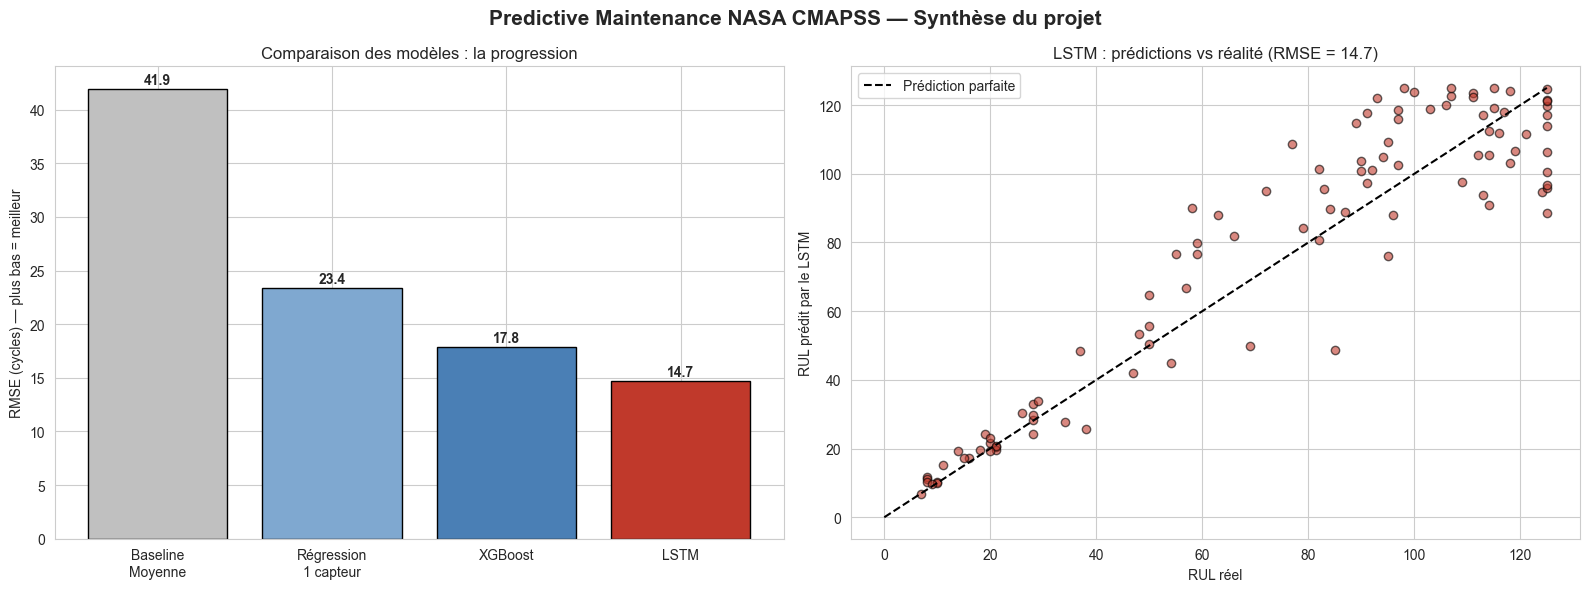

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ===== PANNEAU GAUCHE : comparaison des RMSE =====
modeles = ["Baseline\nMoyenne", "Régression\n1 capteur", "XGBoost", "LSTM"]
scores = [rmse, rmse_lr, rmse_xgb, rmse_lstm]
couleurs = ["#c0c0c0", "#7fa8d0", "#4a7fb5", "#c0392b"]

barres = ax1.bar(modeles, scores, color=couleurs, edgecolor="black")
ax1.set_ylabel("RMSE (cycles) — plus bas = meilleur")
ax1.set_title("Comparaison des modèles : la progression")
# Afficher la valeur au-dessus de chaque barre
for barre, score in zip(barres, scores):
    ax1.text(barre.get_x() + barre.get_width()/2, score + 0.5,
             f"{score:.1f}", ha="center", fontweight="bold")

# ===== PANNEAU DROIT : prédictions LSTM vs réalité =====
ax2.scatter(y_true, y_pred_lstm, alpha=0.6, color="#c0392b", edgecolor="black")
# Ligne de prédiction parfaite (diagonale)
lims = [0, RUL_MAX]
ax2.plot(lims, lims, "k--", label="Prédiction parfaite")
ax2.set_xlabel("RUL réel")
ax2.set_ylabel("RUL prédit par le LSTM")
ax2.set_title(f"LSTM : prédictions vs réalité (RMSE = {rmse_lstm:.1f})")
ax2.legend()

plt.suptitle("Predictive Maintenance NASA CMAPSS — Synthèse du projet", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

Conclusion : 

À gauche — la progression : 4 barres décroissantes, 41.9 → 23.4 → 17.8 → 14.7. L'histoire est limpide : chaque modèle bat le précédent, et le LSTM (rouge) est le champion. C'est l'illustration parfaite du "benchmark first" de ton prof.

À droite — la qualité du LSTM : le nuage de points colle remarquablement à la diagonale (prédiction parfaite). Tu peux même observer un détail intéressant : les points sont très serrés sur la diagonale pour les RUL faibles (en bas à gauche, moteurs proches de la panne) et un peu plus dispersés pour les RUL élevés. C'est exactement ce qu'on veut ! Le modèle est le plus précis quand ça compte le plus — quand le moteur est près de la panne. Phrase en or pour la soutenance : "Le modèle est particulièrement précis sur les faibles RUL, c'est-à-dire au moment critique où il faut décider d'une maintenance."